# Gold Price Prediction — Data Cleaning & Feature Engineering

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, preprocess_data, create_features
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (2290, 6)


,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


## 2. Handle Missing / Invalid Values

In [3]:
print('Missing values:', df.isnull().sum().sum())
print('Date range:', df['Date'].min(), '->', df['Date'].max())
df_clean = df.copy()

Missing values: 0
Date range: 2008-01-02 00:00:00 -> 2018-05-16 00:00:00


## 3. Imputation

In [4]:
df_imputed = df_clean.copy()
print('NaN count:', df_imputed.isnull().sum().sum())

NaN count: 0


## 4. Distribution Comparison Before vs After Imputation

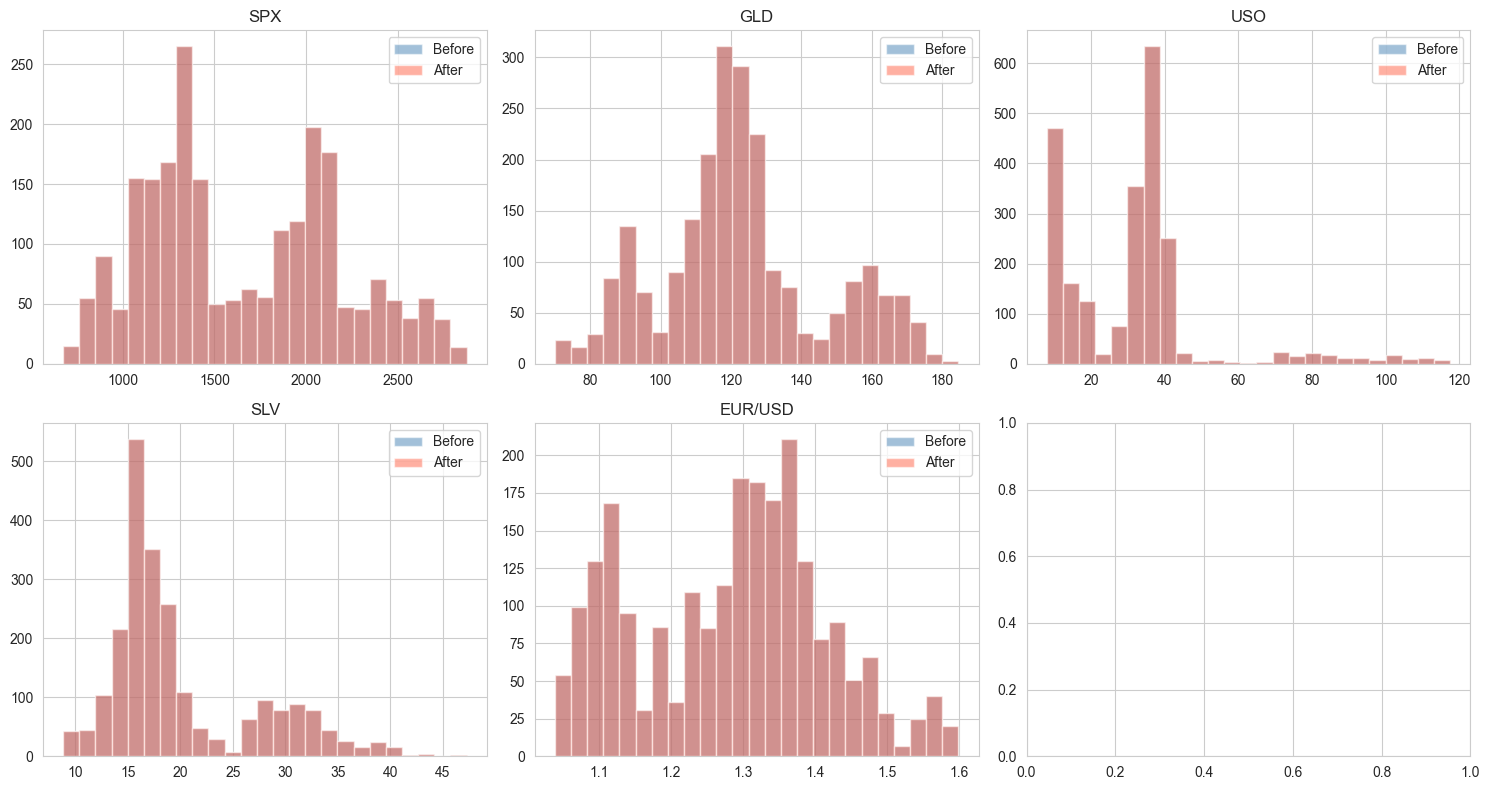

In [5]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
    if col in df_imputed.columns:
        axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [6]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (2290, 17)


,SPX,GLD,USO,SLV,EUR/USD,Year,Month,DayOfWeek,SPX_roll5,SPX_diff,USO_roll5,USO_diff,SLV_roll5,SLV_diff,EUR/USD_roll5,EUR/USD_diff,SLV_USO_ratio
0,1447.160034,84.860001,78.470001,15.180,1.471692,2008,1,2,1447.160034,0.000000,78.470001,0.000000,15.180000,0.000,1.471692,0.000000,0.193450
1,1447.160034,85.570000,78.370003,15.285,1.474491,2008,1,3,1447.160034,0.000000,78.420002,-0.099998,15.232500,0.105,1.473091,0.002799,0.195036
2,1411.630005,85.129997,77.309998,15.167,1.475492,2008,1,4,1435.316691,-35.530029,78.050001,-1.060005,15.210667,-0.118,1.473892,0.001001,0.196184
3,1416.180054,84.769997,75.500000,15.053,1.468299,2008,1,0,1430.532532,4.550049,77.412500,-1.809998,15.171250,-0.114,1.472494,-0.007193,0.199377
4,1390.189941,86.779999,76.059998,15.590,1.557099,2008,1,1,1422.464014,-25.990113,77.142000,0.559998,15.255000,0.537,1.489415,0.088800,0.204970


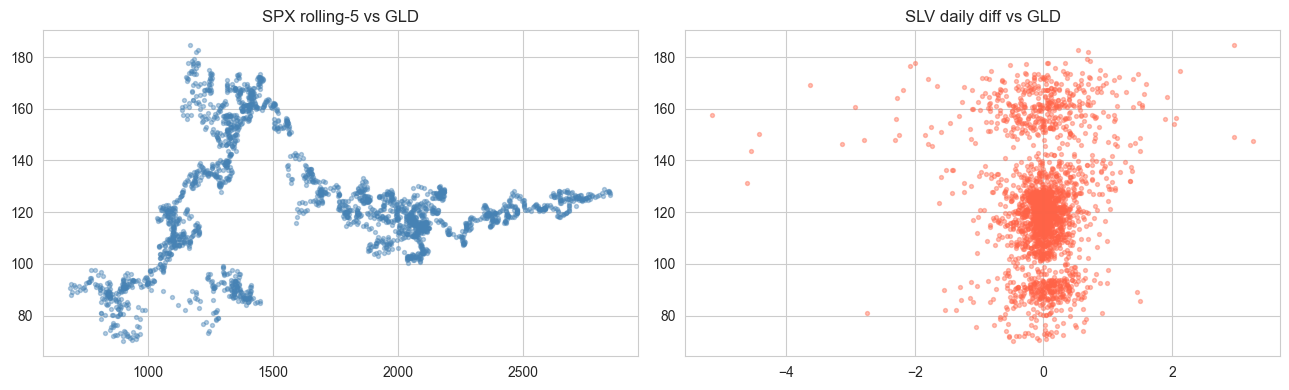

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if 'SPX_roll5' in df_feat.columns:
    axes[0].scatter(df_feat['SPX_roll5'], df_feat['GLD'], alpha=0.4, s=8, color='steelblue')
    axes[0].set_title('SPX rolling-5 vs GLD')
if 'SLV_diff' in df_feat.columns:
    axes[1].scatter(df_feat['SLV_diff'], df_feat['GLD'], alpha=0.4, s=8, color='tomato')
    axes[1].set_title('SLV daily diff vs GLD')
plt.tight_layout(); plt.show()

## 6. Encode Categorical Features

In [8]:
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('Final shape:', df_encoded.shape)

Categorical columns: []
Final shape: (2290, 17)


## 7. Verify & Save Cleaned Dataset

In [9]:
print('Missing values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)
df_encoded.to_csv('data/gold_price_cleaned.csv', index=False)
print('Saved -> data/gold_price_cleaned.csv')
df_encoded.head()

Missing values: 0
Final shape: (2290, 17)
Saved -> data/gold_price_cleaned.csv


,SPX,GLD,USO,SLV,EUR/USD,Year,Month,DayOfWeek,SPX_roll5,SPX_diff,USO_roll5,USO_diff,SLV_roll5,SLV_diff,EUR/USD_roll5,EUR/USD_diff,SLV_USO_ratio
0,1447.160034,84.860001,78.470001,15.180,1.471692,2008,1,2,1447.160034,0.000000,78.470001,0.000000,15.180000,0.000,1.471692,0.000000,0.193450
1,1447.160034,85.570000,78.370003,15.285,1.474491,2008,1,3,1447.160034,0.000000,78.420002,-0.099998,15.232500,0.105,1.473091,0.002799,0.195036
2,1411.630005,85.129997,77.309998,15.167,1.475492,2008,1,4,1435.316691,-35.530029,78.050001,-1.060005,15.210667,-0.118,1.473892,0.001001,0.196184
3,1416.180054,84.769997,75.500000,15.053,1.468299,2008,1,0,1430.532532,4.550049,77.412500,-1.809998,15.171250,-0.114,1.472494,-0.007193,0.199377
4,1390.189941,86.779999,76.059998,15.590,1.557099,2008,1,1,1422.464014,-25.990113,77.142000,0.559998,15.255000,0.537,1.489415,0.088800,0.204970
